# 📊 Unemployment Analysis with Python

**Dataset:** Unemployment in India | **Tools:** Python, Pandas, Seaborn, Plotly

**Objective:** Analyze unemployment trends in India, investigate the impact of COVID-19, identify patterns, and provide insights for policy-making.

---

## 📋 Table of Contents
1. [Import Libraries](#Import-Libraries)
2. [Load Dataset](#Load-Dataset)
3. [Data Cleaning](#Data-Cleaning)
4. [Unemployment Trend Over Time](#Unemployment-Trend-Over-Time)
5. [COVID-19 Impact Analysis](#COVID-19-Impact-Analysis)
6. [Region-wise Comparison](#Region-wise-Comparison)
7. [Top 5 States with Highest Unemployment](#Top-5-States-with-Highest-Unemployment)
8. [Seasonal Trend (Monthly)](#Seasonal-Trend-(Monthly))
9. [Correlation Heatmap](#Correlation-Heatmap)
10. [Interactive Chart with Plotly](#Interactive-Chart-with-Plotly)
11. [Key Insights](#Key-Insights)
12. [Policy Recommendations](#Policy-Recommendations)
13. [Conclusion](#Conclusion)

---

*This analysis explores unemployment data from India, focusing on pre- and post-COVID periods to understand economic impacts.*

###  Import Libraries

In [17]:
# Importing necessary libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

### Load Dataset

In [18]:
# Loading the unemployment dataset
df = pd.read_csv("Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


### Data Cleaning

In [19]:
# Getting an overview of the dataset: data types and non-null counts
df.info()

# Summary statistics for numerical columns
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [20]:
# Checking for missing values in each column
df.isnull().sum()

Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment Rate (%)            28
 Estimated Employed                         28
 Estimated Labour Participation Rate (%)    28
Area                                        28
dtype: int64

In [21]:
# Data cleaning steps
# Drop rows with missing values
df.dropna(inplace=True)

# Clean column names by stripping extra spaces
df.columns = df.columns.str.strip()

# Convert Date column to datetime format (dayfirst=True for DD-MM-YYYY)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Extract Year, Month, and Quarter for easier analysis
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter

# Display cleaned data
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Year,Month,Quarter
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,2
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural,2019,6,2
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural,2019,7,3
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural,2019,8,3
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural,2019,9,3


### Unemployment Trend Over Time

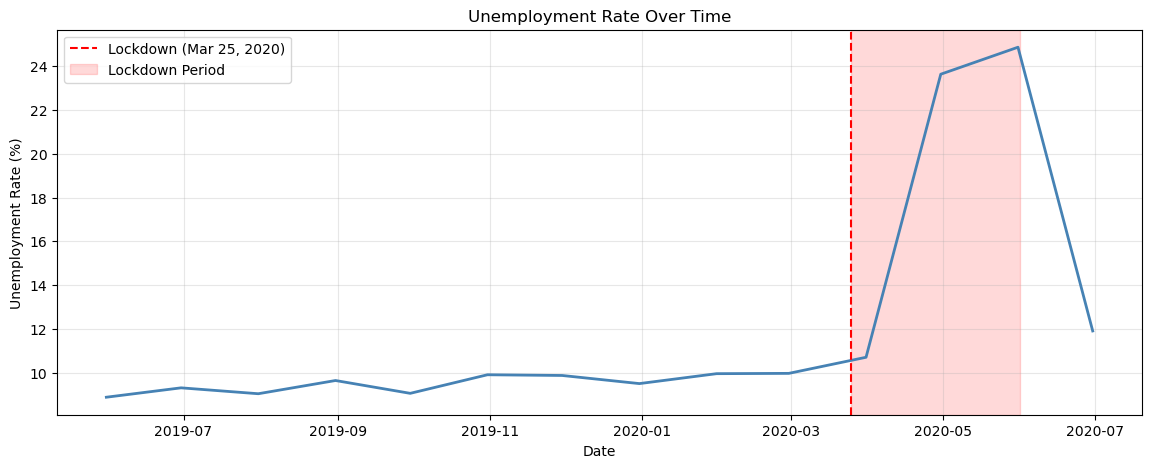

In [22]:
# Analyzing unemployment trend over time
# Group by date and calculate average unemployment rate
monthly_avg = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean().reset_index()

# Plot the trend with lockdown markers
plt.figure(figsize=(14, 5))
plt.plot(monthly_avg['Date'], monthly_avg['Estimated Unemployment Rate (%)'], color='steelblue', linewidth=2)

# Add vertical line for lockdown start
plt.axvline(pd.Timestamp('2020-03-25'), color='red', linestyle='--', linewidth=1.5, label='Lockdown (Mar 25, 2020)')
plt.axvspan(pd.Timestamp('2020-03-25'), pd.Timestamp('2020-06-01'), alpha=0.15, color='red', label='Lockdown Period')

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### COVID-19 Impact Analysis

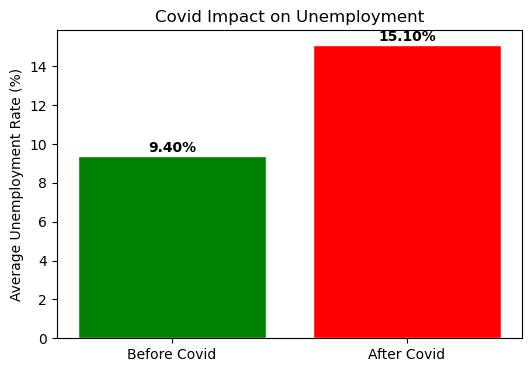

Before COVID avg: 9.40%
After COVID avg : 15.10%
Increase        : +5.70 percentage points


In [23]:
# Comparing unemployment before and after COVID-19
before_covid = df[df['Year'] < 2020]['Estimated Unemployment Rate (%)']
after_covid  = df[df['Year'] >= 2020]['Estimated Unemployment Rate (%)']

labels = ['Before Covid', 'After Covid']
values = [before_covid.mean(), after_covid.mean()]

# Bar plot to visualize the comparison
plt.figure(figsize=(6, 4))
plt.bar(labels, values, color=['green', 'red'], edgecolor='white')
plt.title("Covid Impact on Unemployment")
plt.ylabel("Average Unemployment Rate (%)")
for i, v in enumerate(values):
    plt.text(i, v + 0.2, f'{v:.2f}%', ha='center', fontweight='bold')
plt.show()

# Print the averages and increase
print(f"Before COVID avg: {before_covid.mean():.2f}%")
print(f"After COVID avg : {after_covid.mean():.2f}%")
print(f"Increase        : +{after_covid.mean() - before_covid.mean():.2f} percentage points")

### Region-wise Comparison

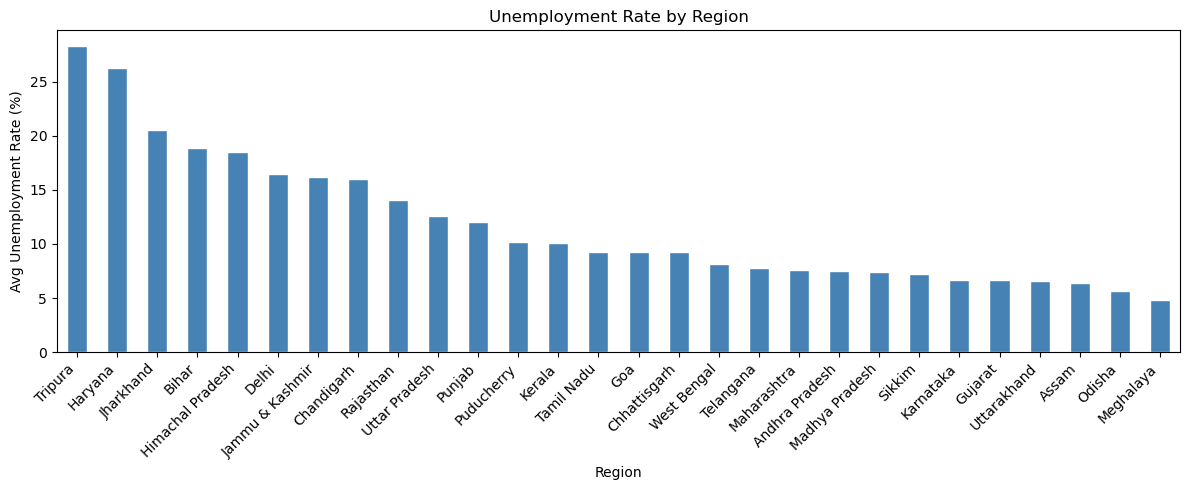

In [24]:
# Comparing unemployment rates across different regions
region_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)

# Bar plot for region-wise comparison
plt.figure(figsize=(12, 5))
region_avg.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title("Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Avg Unemployment Rate (%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Top 5 States with Highest Unemployment

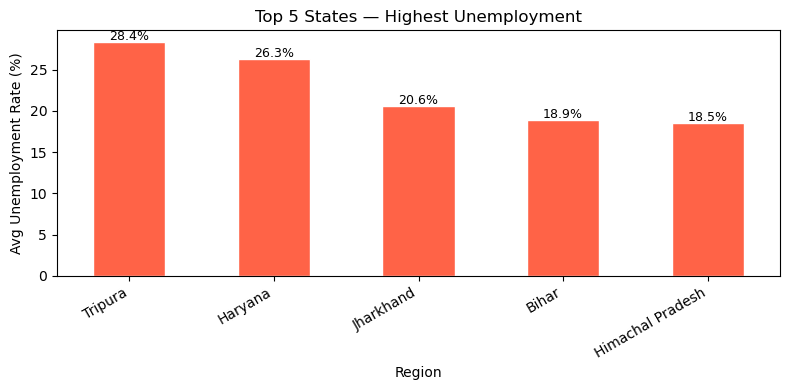

In [25]:
# Identifying top 5 states with highest unemployment
top5 = region_avg.head(5)

# Bar plot for top 5
plt.figure(figsize=(8, 4))
top5.plot(kind='bar', color='tomato', edgecolor='white')
plt.title("Top 5 States — Highest Unemployment")
plt.ylabel("Avg Unemployment Rate (%)")
plt.xticks(rotation=30, ha='right')
for i, v in enumerate(top5):
    plt.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

###  Seasonal Trend (Monthly)

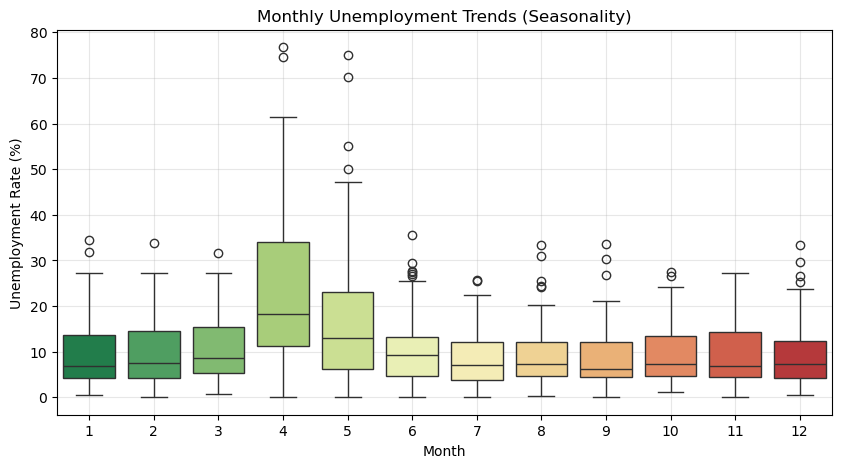

In [26]:
# Exploring seasonal patterns in unemployment (monthly boxplot)
plt.figure(figsize=(10, 5))
sns.boxplot(x='Month', y='Estimated Unemployment Rate (%)', data=df, palette='RdYlGn_r')
plt.title("Monthly Unemployment Trends (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True, alpha=0.3)
plt.show()

### Correlation Heatmap

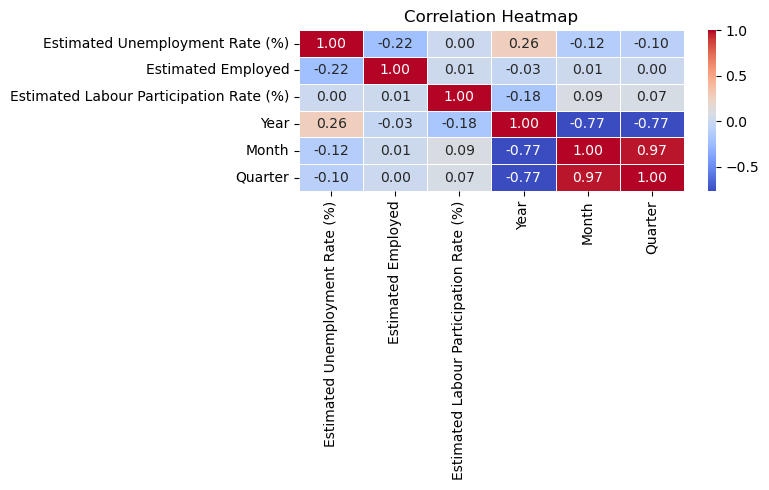

In [27]:
# Correlation heatmap to see relationships between numerical variables
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8, 5))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Interactive Chart with Plotly

In [28]:
# Interactive line chart using Plotly for better exploration
fig = px.line(
    monthly_avg,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    title='Unemployment Rate Over Time (Interactive)',
    template='plotly_dark'
)

# Add lockdown annotation
lockdown_date = pd.Timestamp('2020-03-25').timestamp() * 1000  # Plotly uses milliseconds
fig.add_vline(x=lockdown_date, line_color='red', line_dash='dash',
              annotation_text='Lockdown', annotation_position='top right')

fig.show()

## 🔍 Key Insights

1. **📈 COVID-19 Impact:** Unemployment spiked sharply in **April–May 2020** right after the nationwide lockdown was announced on March 25, 2020.

2. **📊 Before vs After COVID:**
   - Average unemployment **before COVID:** 9.40%
   - Average unemployment **after COVID:** 15.10%

3. **🌍 Regional Imbalance:** Some states consistently show much higher unemployment than others, indicating structural economic differences across regions.

4. **📅 Seasonal Patterns:** Certain months (especially Q1 and Q2) show higher unemployment, likely linked to agricultural cycles and seasonal industries.

5. **🔄 Recovery Trend:** After the COVID peak, unemployment rates gradually declined — but have **not fully returned** to pre-pandemic levels, suggesting lasting economic damage.

## 💡 Policy Recommendations

1. **🚀 Emergency Employment Programs** — Launch job schemes during crises to absorb sudden unemployment shocks.
2. **🏭 Support Small Businesses** — MSMEs need credit access and relief during economic disruptions as they are the largest employers.
3. **🎓 Skill Development** — Focus training programs in states with consistently high unemployment.
4. **🛡️ Strengthen Social Security** — Better unemployment benefits will protect workers during sudden job losses.

## 🎯 Conclusion

This analysis clearly shows that **COVID-19 was the biggest disruption** to India's labour market in the studied period. Unemployment surged during lockdowns and recovery has been slow and uneven across states. Targeted policy action in the most affected regions is essential for long-term employment stability.
